# Usando Diferentes Distribuciones para Diferentes Procesos

En la sesión anterior, mencionamos que si bien es un consejo útil comenzar haciendo que todas las distribuciones en nuestro modelo sean Exponenciales (porque es fácil ajustar una Distribución Exponencial), para los modelos del mundo real probablemente queramos adaptarlas para usar una Distribución Lognormal para los tiempos de actividad.

> vamos a explorar la Lognormal como una buena distribución para trabajar con tiempos de actividad, ¡y casi siempre lo es\!

Una Distribución Lognormal se usa comúnmente en la simulación de Eventos Discretos para modelar el tiempo para realizar una tarea. Es **sesgada a la derecha**, lo que básicamente significa que tiene una cola larga. Para ponerlo en términos más comprensibles, sugiere que la mayoría de los tiempos de actividad serán similares, pero algunos serán más largos y otros MUCHO más largos. Esto tiende a capturar bien los tiempos de actividad (por ejemplo, lasrutas de los pacientes).

## Un poco de contexto

> La buena noticia es que usaremos un código preescrito para especificar nuestra lognormal, y todo lo que necesitaremos saber para hacer esto es la media (promedio) de tiempo para nuestra actividad, y la desviación estándar (una medida de cuánto varían los tiempos en el conjunto de datos que Python puede calcular por nosotros si se le da una lista de tiempos de actividad). Sin embargo, es útil tener una idea un poco más clara sobre qué es una lognormal, lo cual veremnos a más abajo. Para empezar tengan presente que la lognormal es buena para los tiempos de actividad en general, y la distribución exponencial es buena para los tiempos entre llegadas (como el tiempo entre la llegada de los pacientes).

### La distribución normal

Una distribución normal es una curva en forma de campana que es simétrica. Se define por dos parámetros: μ (Mu) y σ (Sigma), que representan la media y la desviación estándar de la distribución. Por lo tanto, es fácil introducir dichos valores de nuestros propios datos.

### Logaritmos

Antes de continuar, recordemos algo que muchos de nosotros aprendimos en la escuela (y luego olvidamos rápidamente): los logaritmos.

Los logaritmos son básicamente lo opuesto a los exponenciales.

Efectivamente, los logaritmos se relacionan con cuántas copias de un número se multiplican entre sí para obtener otro número.

¿Cuántos 4 se multiplican para obtener 64?

```
4 x 4 x 4 = 64
```

Tuvimos que multiplicar 3 copias del número 4 para obtener 64.

Esto significa que el logaritmo es 3.

Lo escribiríamos como
$$Y = log_4(64) = 3$$

### Distribuciones lognormales

¿Cómo se relaciona esto con la distribución?

Bueno, una distribución Lognormal es aquella en la que el **logaritmo** de la variable aleatoria que estamos modelando se distribuye normalmente.

Esto significa que los dos parámetros μ (Mu) y σ (Sigma) utilizados para especificar una distribución Lognormal no representan la media y la desviación estándar, a diferencia de la distribución normal; más bien, representan lo que se conoce como la localización y la escala de la distribución, respectivamente.

:::{.callout-note}
μ (Mu) y σ (Sigma) representan la media y la desviación estándar una vez que los datos en la distribución lognormal se han transformado usando logaritmos.
:::

Es fácil obtener la media y la desviación estándar de nuestros datos.

Si usáramos la distribución Normal, podríamos hacer eso.

> La distribución Normal a menudo no es buena para los tiempos de actividad
>
>  - Permite valores negativos
>  - Las distribuciones de actividad rara vez son simétricas, es más probable que sean un poco "irregulares" (sesgadas), con solo unas pocas actividades siendo mucho más largas.

El problema es que no podemos simplemente darle a una distribución Lognormal la media y la desviación estándar, porque en una distribución Lognormal, la media y la desviación estándar de nuestros datos están representadas en la distribución normal subyacente, no en la distribución Lognormal (recuerda, son los logaritmos de los valores los que se distribuyen normalmente).

>**Entonces, ¿qué hacemos?**
>
> Necesitamos convertir nuestros valores de media y desviación estándar (que obtenemos de nuestros datos del mundo real) en μ y σ para una distribución Lognormal.
>
> **¡Esta es la parte clave que necesitan entender\!**

## Código para la distribución lognormal

```python
import numpy as np
import math

class Lognormal:
    """
    Encapsula una distribución lognormal
    """
    def __init__(self, mean, stdev, random_seed=None):
        """
        Parámetros:
        -------
        mean = media de la distribución lognormal
        stdev = desviación estándar de la distribución lognormal
        """
        self.rand = np.random.default_rng(seed=random_seed)
        mu, sigma = self.normal_moments_from_lognormal(mean, stdev**2)
        self.mu = mu
        self.sigma = sigma

    def normal_moments_from_lognormal(self, m, v):
        '''
        Devuelve mu y sigma de la distribución normal
        subyacente a una lognormal con media m y varianza v
        fuente: https://blogs.sas.com/content/iml/2014/06/04/simulate-lognormal
        -data-with-specified-mean-and-variance.html

        Parámetros:
        -------
        m = media de la distribución lognormal
        v = varianza de la distribución lognormal

        Retorna:
        -------
        (float, float)
        '''
        phi = math.sqrt(v + m**2)
        mu = math.log(m**2/phi)
        sigma = math.sqrt(math.log(phi**2/m**2))
        return mu, sigma

    def sample(self):
        """
        Muestrear de la distribución normal
        """
        return self.rand.lognormal(self.mu, self.sigma)
```

Agregaremos esto a nuestro código del modelo. Luego solo necesitamos asegurarnos de tener tanto una media como una desviación estándar para los tiempos de actividad que queremos representar en distribuciones Lognormales. Cuando necesitamos muestrear un tiempo de actividad, creamos una instancia de la clase Lognormal con nuestra media y desviación estándar, y llamamos al método `sample`.

Vamos a hacer esto en el método `attend_clinic` de la clase `Model`.

```python
def attend_clinic(self, patient):
        # Actividad de consulta de enfermería
        start_q_nurse = self.env.now

        with self.nurse.request(priority=patient.priority) as req:
            yield req

            end_q_nurse = self.env.now

            patient.q_time_nurse = end_q_nurse - start_q_nurse

            if self.env.now > g.warm_up_period:
                self.results_df.at[patient.id, "Q Time Nurse"] = (
                    patient.q_time_nurse
                )

            ##NUEVO - ahora usamos una distribución lognormal para el tiempo de actividad,
            # así que creamos una instancia de nuestra clase Lognormal con la media
            # y las desviaciones estándar especificadas en la clase g, y luego muestreamos
            # de ella (hacemos esto en una sola línea de código aquí, tal como lo
            # hicimos al muestrear de la distribución exponencial antes).
            sampled_nurse_act_time = Lognormal(
                g.mean_n_consult_time, g.sd_n_consult_time).sample()

            yield self.env.timeout(sampled_nurse_act_time)
```

A continuación, se presenta una descripción general de cómo usar las clases y de las diferentes distribuciones incluidas:

# Variables aleatorias y simulación

Si trabajas en modelado de simulación en Python, es muy probable que necesites usar el espacio de nombres `numpy.random`. Este ofrece una variedad de distribuciones estadísticas que puedes usar para muestrear de forma eficiente. Veamos algunas distribuciones de ejemplo. Por ejemplo, generaremos 100 000 muestras de las distribuciones uniforme, exponencial y normal:


## 1. Importaciones

Importaremos `numpy` para el muestreo y `matplotlib` para graficar nuestras distribuciones.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

## 2. Funciones auxiliares

La función sencilla a continuación puede usarse para producir automáticamente una gráfica que ilustre la distribución de las muestras.


In [ ]:
def distribution_plot(samples, bins=100, figsize=(5,3)):
    '''
    Función auxiliar para visualizar las distribuciones.
    
    Parámetros:
    -----------
    samples: np.ndarray
        Un array de numpy con datos cuantitativos para graficar como un histograma.
        
    bins: int, opcional (default=100)
        El número de contenedores (bins) a incluir en el histograma.
        
    figsize: (int, int)
        Tamaño del gráfico en píxeles.
        
    Retorna:
    --------
        fig, ax: una tupla que contiene los objetos de figura y ejes de matplotlib.
    '''
    hist = np.histogram(samples, bins=np.arange(bins), 
                        density=True)
    
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot()
    _ = ax.plot(hist[0])
    _ = ax.set_ylabel('p(x)')
    _ = ax.set_xlabel('x')
    
    return fig, ax

## 3. Creación de un objeto generador de números aleatorios


Para crear un `Generator`, usa la función `default_rng()` del módulo `random`.

Para más información sobre `Generator`, puedes consultar la [documentación de `numpy`.](https://numpy.org/doc/stable/reference/random/generator.html)


In [ ]:
rng = np.random.default_rng()

In [ ]:
type(rng)

## 4. Pasos para crear una muestra

En general, el enfoque para muestrear es:

1. Crear un objeto generador de números aleatorios.
2. Con ese objeto, llamar el método de la distribución estadística.
    * Cada método tiene sus propios parámetros.
    * Cada método incluye un parámetro `size` que se usa para indicar cuántas muestras generar.
3. Guardar el resultado en una variable con un nombre apropiado.

### 4.1 Distribución uniforme


In [ ]:
# paso 1: crear un objeto generador de números aleatorios
rng = np.random.default_rng()

# paso 2 y 3: llamar al método apropiado del generador y almacenar el resultado
samples = rng.uniform(low=10, high=40, size=1000000)

# ilustrar con un gráfico.
fig, ax = distribution_plot(samples, bins=50)

### 4.2 Distribución exponencial


In [ ]:
rng = np.random.default_rng()
samples = rng.exponential(scale=12, size=1_000_000)
distribution_plot(samples, bins=50)

## 4.3 Distribución normal


In [ ]:
rng = np.random.default_rng()
samples = rng.normal(loc=25.0, scale=5.0, size=1_000_000)
distribution_plot(samples, bins=50)

## 4.4 Generación de una sola muestra

Si solo necesitamos generar una única muestra, omitimos el parámetro `size`. Esto devuelve un valor escalar.


In [ ]:
rng = np.random.default_rng()
sample = rng.normal(loc=25.0, scale=5.0)
print(sample)
print(type(sample))

Ten en cuenta que también puedes establecer `size` en 1. Solo que, en ese caso, se devuelve un arreglo. Por ejemplo:


In [ ]:
rng = np.random.default_rng()
sample = rng.normal(loc=25.0, scale=5.0, size=1)
# se devuelve un array de numpy
print(sample)
print(type(sample))

# para acceder al valor escalar, usa el índice 0 del array.
print(sample[0])

## 5. Control del muestreo en simulaciones

En una simulación, podemos controlar los flujos de números seudoaleatorios y, por lo tanto, hacer que nuestros resultados sean repetibles.

> **Estocástico** se refiere a un modelo probabilístico. Esto significa que una sola corrida del modelo no ofrece un panorama preciso del desempeño o comportamiento del modelo. Necesitas ejecutar el modelo múltiples veces para obtener una distribución.

La mejor manera de explicar la idea de flujos y repetibilidad es mediante un modelo sencillo. Volvamos a mirar `numpy.random.Generator`.


Consideren el caso donde estamos modelando la duración de la estancia de un paciente en un hospital.

* En esta ruta/proceso, los pacientes se someten a un procedimiento que requiere, en promedio, una estancia de 3 días en el hospital.

Probemos un modelo simple en el que muestreamos la duración de la estancia de los pacientes. Modelaremos la variable de duración de la estancia usando la distribución exponencial.

El primer problema que encontraremos es la repetibilidad.


In [ ]:
N_PATIENTS = 5
MEAN_LOS = 3.0

# crear un objeto generador aleatorio
rng = np.random.default_rng()

# el parámetro de escala = media
sample_acute = rng.exponential(scale=MEAN_LOS, size=N_PATIENTS)

# mostrar los detalles del paciente (en días)
sample_acute

### 5.1 Problema: repetibilidad

El primer problema que encontramos es la repetibilidad. Cada vez que ejecutes el código anterior obtendrás un resultado diferente. Para cualquier estudio científico que produzcamos o publiquemos, queremos que los resultados sean repetibles. En la práctica, la falta de repetibilidad hace muy difícil depurar, probar y corregir el código. Podemos resolver este problema usando una semilla aleatoria. Esto es simplemente un parámetro que pasamos a `default_rng`. Intenta ejecutar el código de abajo varias veces: deberías obtener los mismos resultados en cada corrida.


In [ ]:
N_PATIENTS = 5
MEAN_LOS = 3.0
SEED = 42

# crear objetos generadores aleatorios y establecer la SEMILLA (SEED).
rng = np.random.default_rng(SEED)

# el parámetro de escala = media
sample_acute = rng.exponential(scale=MEAN_LOS, size=N_PATIENTS)

# mostrar los detalles del paciente (en días)
sample_acute

## 6. Encapsular distribuciones, parámetros y semillas aleatorias

Al construir un modelo de simulación suele ser útil *empaquetar* tanto un generador de números aleatorios, los parámetros de una distribución específica y una semilla dentro de una clase de Python. Esto permite crear generadores con facilidad, muestrear de forma directa y mejorar la gestión de flujos para cada actividad del modelo de simulación.

Como ejemplo, presentamos una clase `Exponential` que representa la distribución exponencial. Acepta como parámetro el valor medio y permite fijar la semilla aleatoria.

Luego instanciamos dos objetos `Exponential` para dos procesos diferentes en nuestra simulación: la duración de la estancia aguda y la duración de la estancia de rehabilitación.


In [ ]:
class Exponential:
    '''
    Clase de conveniencia para la distribución exponencial.
    Empaqueta los parámetros de la distribución, la semilla y el generador aleatorio.
    '''
    def __init__(self, mean, random_seed=None):
        '''
        Constructor

        Parámetros:
        -----------
        mean: float
            La media de la distribución exponencial

        random_seed: int, opcional (default=None)
            Una semilla aleatoria para reproducir las muestras. Si se establece en None,
            se crea una muestra única.
        '''
        self.rand = np.random.default_rng(seed=random_seed)
        self.mean = mean

    def sample(self, size=None):
        '''
        Genera una muestra de la distribución exponencial.

        Parámetros:
        -----------
        size: int, opcional (default=None)
            El número de muestras a devolver. Si size=None, se devuelve
            una única muestra.
        '''
        return self.rand.exponential(self.mean, size=size)

# Muestreo usando `sim_tools`


Para reducir la cantidad de código que necesitas escribir para implementar el muestreo de distribuciones, puedes usar el paquete [`sim-tools`](https://pypi.org/project/sim-tools/). La documentación de `sim-tools` está disponible [aquí](https://tommonks.github.io/sim-tools).

El paquete `sim-tools` busca ofrecer implementaciones en Python de todas las distribuciones comunes que se encuentran en software comercial de simulación de eventos discretos, mediante clases fáciles de usar. Esto incluye varias distribuciones que no están implementadas directamente en `numpy`.

## Instalación

El paquete `sim-tools` está incluido en el entorno virtual de conda `sim`. Para instalarlo manualmente, puedes usar el siguiente comando:

```
pip install sim-tools
```

> El código siguiente usa `sim-tools` >= 0.3.3. Esto funciona con Python >= 3.10


## Resumen de las distribuciones implementadas

1. `Exponential`: clase para modelar el tiempo entre eventos en un proceso de Poisson, donde los eventos ocurren de manera continua e independiente a una tasa promedio constante. Acepta la media de la distribución y una semilla aleatoria opcional como parámetros.

2. `Bernoulli`: clase que modela un proceso con solo dos posibles resultados (éxito o fracaso). Recibe la probabilidad de éxito y una semilla aleatoria opcional.

3. `Lognormal`: clase usada cuando el logaritmo de la variable está distribuido normalmente. Recibe la media y la desviación estándar de la distribución lognormal, y una semilla aleatoria opcional.

4. `Normal`: clase para variables con distribución normal. Recibe la media, la desviación estándar (`sigma`), un booleano para permitir o no valores negativos, y una semilla aleatoria opcional.

5. `Uniform`: clase para variables donde todos los resultados son igualmente probables. Recibe los límites inferior y superior de la distribución uniforme y una semilla aleatoria opcional.

6. `Triangular`: clase para variables cuya probabilidad es máxima en la moda (pico) y decrece de forma uniforme a ambos lados. Recibe el límite inferior, la moda, el límite superior y una semilla aleatoria opcional.

7. `FixedDistribution`: clase que devuelve un valor fijo; útil cuando se requiere un valor constante en una simulación. Recibe ese valor fijo como parámetro.

8. `CombinationDistribution`: clase para modelar procesos cuyo resultado es la suma de resultados provenientes de múltiples distribuciones. Recibe instancias de varias distribuciones como parámetros.

9. `ContinuousEmpirical`: clase para modelar un proceso basado en datos observados, donde la probabilidad de un resultado es proporcional a su frecuencia en los datos. Para producir un valor continuo se usa interpolación lineal entre los límites. Recibe límites inferiores (de una distribución empírica discreta), límites superiores, frecuencias observadas y una semilla aleatoria opcional.

10. `Erlang`: clase para modelar el tiempo entre eventos en un proceso de Poisson. Está implementada para que el usuario proporcione la media y la desviación estándar en lugar de `k` y `theta`, lo que la hace compatible con otros paquetes comerciales. Internamente, la media y la desviación estándar se convierten a `k` y `theta`.

    El Erlang es un caso especial de la distribución gamma donde `k` es un entero. Internamente se implementa usando el método `gamma` del `Generator` de `numpy`. Como `k` se calcula a partir de la media y la desviación estándar, se redondea a un valor entero usando la función incorporada `round` de Python. Opcionalmente, el usuario puede desplazar el origen de la distribución con el parámetro de ubicación (`location`).

11. `ErlangK`: igual que `Erlang`, pero el usuario especifica directamente `k` y `theta`.

12. `Weibull`: distribución caracterizada por un parámetro de forma (`alpha`) y uno de escala (`beta`), ambos mayores que cero. El parámetro de escala influye en la varianza de las muestras. De forma opcional, un parámetro de ubicación puede desplazar la distribución para fijar un límite inferior. Útil para modelar vida útil de materiales y sistemas con tasas de falla no constantes en el tiempo.

13. `Gamma`: clase definida por parámetros `alpha` (forma) y `beta` (escala). Incluye métodos para calcular media y varianza, y un método estático para determinar `alpha` y `beta` a partir de una media y varianza específicas. A menudo se usa para modelar tiempos de espera para múltiples eventos en un proceso de Poisson.

14. `Beta`: clase que acepta dos parámetros de forma (`alpha1` y `alpha2`) y puede reescalar a un rango específico usando límites inferior y superior. Común para modelar variables acotadas a un intervalo, como proporciones y porcentajes.

15. `Discrete`: clase que permite muestrear de un conjunto de valores con frecuencias dadas. Útil para escenarios donde los resultados tienen probabilidades específicas, por ejemplo porcentajes de enrutamiento o clases de entidades.

16. `TruncatedDistribution`: clase que puede truncar cualquier distribución dada en un límite inferior especificado. Es útil cuando se modelan variables con un límite inferior natural y se desea asegurar que no se muestren valores por debajo de ese umbral.

17. `RawEmpirical`: clase que permite muestrear con reemplazo a partir de una lista de valores empíricos crudos. Es útil cuando ninguna distribución teórica se ajusta bien a los datos observados y se prefiere un enfoque no paramétrico.

18. `PearsonV` (tipo 5 de Pearson), también conocida como distribución gamma inversa, caracterizada por dos parámetros: `alpha` (forma) y `beta` (escala), ambos mayores que cero. Útil para modelar retrasos temporales con un mínimo pero sin un máximo acotado. La media y la varianza pueden calcularse directamente para ciertos valores del parámetro de forma.

19. `PearsonVI` (tipo 6 de Pearson), una distribución beta invertida, definida por tres parámetros: `alpha1` (forma 1), `alpha2` (forma 2) y `beta` (escala), todos mayores que cero. Puede emplearse para modelar tiempos de finalización de tareas; se muestrea mediante la transformación `Pearson6(a1, a2, b) = b * X / (1 - X)`, donde `X` es una variable beta con parámetros `alpha1` y `alpha2`. La media y la varianza pueden calcularse directamente para ciertos valores del segundo parámetro de forma.


## Importación de clases de distribución

El módulo `sim_tools.distributions` contiene todas las clases de distribución.


In [ ]:
# import all distributions
from sim_tools.distributions import (
    Exponential,
    Poisson,
    Bernoulli,
    Lognormal,
    Normal,
    Uniform,
    Triangular,
    FixedDistribution,
    CombinationDistribution,
    ContinuousEmpirical,
    Erlang,
    ErlangK,
    Weibull,
    Gamma,
    Beta,
    Discrete,
    PearsonV,
    PearsonVI,
)

## Crear y visualizar las distribuciones

El código de abajo crea una instancia de las distribuciones disponibles. Aquí usamos el parámetro `size` en `sample()` para producir un gran número de muestras y así permitir la visualización y el trazado de histogramas.


In [ ]:
import matplotlib.pyplot as plt

# Create an instance of each distribution and generate 10,000 samples
distributions = [
    Exponential(mean=1.0, random_seed=42),
    Poisson(rate=1.0, random_seed=42),
    Erlang(mean=32.0, stdev=9.26, location=2.83, random_seed=42),
    ErlangK(k=3, theta=1.0, location=0.0, random_seed=42),
    Bernoulli(p=0.3, random_seed=42),
    Lognormal(mean=10, stdev=1, random_seed=42),
    Normal(mean=0, sigma=1, allow_neg=True, random_seed=42),
    Uniform(low=0, high=1, random_seed=42),
    Triangular(low=0, mode=0.5, high=1, random_seed=42),
    FixedDistribution(value=5),
    CombinationDistribution(
        Exponential(mean=1.0), Normal(mean=0, sigma=1, allow_neg=True)
    ),
    ContinuousEmpirical(
        lower_bounds=[0, 5, 10, 15, 30, 45, 60, 120, 180, 240, 480],
        upper_bounds=[5, 10, 15, 30, 45, 60, 120, 180, 240, 480, 2880],
        freq=[34, 4, 8, 13, 15, 13, 19, 13, 9, 12, 73],
        random_seed=42,
    ),
    Weibull(alpha=1.93, beta=19.15, random_seed=42),
    Gamma(alpha=2.84, beta=7.42, location=0.0, random_seed=42),
    Beta(alpha1=1.32, alpha2=2.56, lower_bound=10.0, upper_bound=15.0, random_seed=42),
    Discrete(values=[1, 2, 3], freq=[95, 3, 2], random_seed=42),
    PearsonV(alpha=10.0, beta=2.5, random_seed=42),
    PearsonVI(alpha1=10.0, alpha2=5.0, beta=0.85, random_seed=42),
]

fig, axs = plt.subplots(len(distributions) // 2, 2, figsize=(15, 15))

for i, distribution in enumerate(distributions):
    row = i // 2
    col = i % 2
    samples = distribution.sample(size=100_000)
    axs[row, col].hist(samples, bins=30, alpha=0.7)
    axs[row, col].set_title(distribution.__class__.__name__)

fig.tight_layout()
plt.show()

## Generación de muestras individuales

En una simulación de eventos discretos es más común generar muestras a medida que avanza el tiempo. El siguiente ejemplo ilustra cómo generar muestras individuales a partir de las distribuciones `Exponential` y `ContinuousEmpirical`.


In [ ]:
arrival_dist = Exponential(mean=30, random_seed=42)
arrival_dist.sample()

In [ ]:
activity_time = ContinuousEmpirical(
    lower_bounds=[0, 5, 10, 15, 30, 45, 60, 120, 180, 240, 480],
    upper_bounds=[5, 10, 15, 30, 45, 60, 120, 180, 240, 480, 2880],
    freq=[34, 4, 8, 13, 15, 13, 19, 13, 9, 12, 73],
    random_seed=42,
)

activity_time.sample()

In [ ]:
acute_los = Exponential(3.0, random_seed=42)
rehab_los = Exponential(30.0, random_seed=101)

In [ ]:
acute_los.sample()

In [ ]:
rehab_los.sample()

Ahora podemos pasar a crear modelos con `simpy` que utilicen el muestreo de `numpy`.


# Selección y parametrización de distribuciones usando datos del mundo real

Más allá de usar algunas distribuciones estándar que suelen ajustarse bien a ciertos fenómenos, como por ejemplo:

- **lognormal** para tiempos de actividad
- **exponencial** para tiempos entre llegadas

y de parametrizarlas con los promedios (y, cuando aplique, medidas de dispersión) obtenidos de nuestros datos reales, podemos ir un paso más allá y emplear una distribución con una **forma diferente** que refleje aún más fielmente nuestros datos del mundo real.

## El paquete *fitter*

Vamos a utilizar el paquete [**fitter**](https://github.com/cokelaer/fitter).

```
pip install fitter
```

o

```
conda install -c bioconda fitter
```

*fitter* proporciona funciones de ayuda para encontrar la **distribución más apropiada** para tus datos reales y, después, devolver la distribución y todos los **parámetros** relevantes.

### Una demostración rápida de *fitter*

Comencemos con un CSV de ejemplo de tiempos históricos de actividad.

In [1]:
import pandas as pd

df = pd.read_csv("complex_event_log.csv")

df = df[df["event"].isin(["MINORS_examination_begins", "MINORS_examination_complete"])]

df = df[["entity_id","run", "event", "time"]]

df = df.pivot(index=["entity_id", "run"], columns="event", values="time").reset_index()

df["duration"] = df["MINORS_examination_complete"] - df["MINORS_examination_begins"]

df["P_ID"] = df.apply(lambda x: f'{x["entity_id"]:.0f}_{x["run"]:.0f}', axis=1)

df = df[~df["duration"].isna()]

df[["P_ID","duration"]].to_csv("MINORS_examination_duration.csv", index=False)

Aquí tenemos un *dataframe* con la duración histórica de un paso concreto de un proceso: la duración de una cita con enfermería.

In [2]:
import pandas as pd

df = pd.read_csv("MINORS_examination_duration.csv")

df.head()

,P_ID,duration
0,1_0,16.217771
1,1_1,16.527785
2,1_2,13.318456
3,1_3,16.115894
4,1_4,15.033374


Para empezar, **visualicémosla**.

In [3]:
import plotly.express as px

px.histogram(df["duration"].round(1))

A primera vista, parece una **normal**: una curva acampanada con colas aproximadamente simétricas. Pero ¿qué parámetros necesitamos? ¿Y es *seguro* que sea normal?

> Reflexiona cuidadosamente sobre las variables para las que decides ajustar distribuciones.
>
> Probablemente quieras muestrear aleatoriamente distribuciones para **tus duraciones de actividad** y **tus tiempos entre llegadas**; pero **no** querrás usar distribuciones históricas de **tiempos de espera**, ya que estos deberían **emerger** del diseño de tu simulación (número de recursos, probabilidades de que las personas realicen distintas actividades, etc.) y no venir impuestos por datos históricos, que además suelen reflejar **actividad** y no **demanda** pura.

### Limitar *fitter* a distribuciones comunes

Por defecto, *fitter* examina **todas** las distribuciones que ofrece la librería *scipy*.

Esto puede hacer que te recomiende distribuciones **poco habituales**, quizá menos apropiadas.

En su lugar, es recomendable limitar *fitter* a un **conjunto básico** de distribuciones.

In [4]:
distributions_to_scan = [
            "poisson",
            "bernoulli",
            "triang",
            "erlang",
            "weibull_min",
            "expon_weib",
            "betabinom",
            "pearson3",
            "cauchy",
            "chi2",
            "expon",
            "exponpow",
            "gamma",
            "lognorm",
            "norm",
            "powerlaw",
            "rayleigh",
            "uniform"
        ]

> Anteirormente hablamos del paquete `sim-tools`, el cual es una alternativa a *scipy* para gestionar distribuciones.
>
> En ese caso, te convendría pasar la lista de distribuciones admitidas por **sim-tools** vistas previamente.

## Ajuste con *fitter*

In [17]:
from fitter import Fitter

f = Fitter(df["duration"], distributions=distributions_to_scan, timeout=60)

f.fit()

El método `summary` devuelve una salida con varias distribuciones candidatas y **qué tan bien** se ajustan.

En este ejemplo, **gamma**, **erlang**, **lognorm**, **pearson3** y **norm** parecen aproximar muy bien los datos; la **gamma** resulta ser el **mejor ajuste**, aunque la diferencia es pequeña.

,sumsquare_error,aic,bic,kl_div,ks_statistic,ks_pvalue
gamma,0.003110,854.790795,-116008.847132,inf,0.004345,0.998265
erlang,0.003110,854.792833,-116008.842057,inf,0.004342,0.998284
lognorm,0.003110,854.803532,-116008.718236,inf,0.004365,0.998137
pearson3,0.003110,854.790946,-116008.619333,inf,0.004371,0.998098
norm,0.003112,853.003887,-116012.812344,inf,0.004655,0.995350


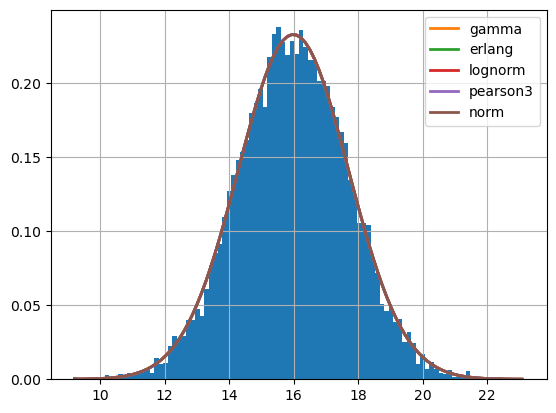

In [18]:
nurse_appt_duration_fit = f.summary()

nurse_appt_duration_fit

> Cada columna mide la **calidad del ajuste**; algunas penalizan además la **complejidad** excesiva.
>
> Mejor cuanto **más pequeño**: `sumsquare_error`, `aic`, `bic`, `ks_statistic`  
> Mejor cuanto **más grande**: `ks_pvalue`

Ahora extraigamos los detalles de la **mejor** distribución.

Esto devuelve un **diccionario** con los parámetros necesarios para configurar la distribución con alguna de las librerías de Python para distribuciones.

In [19]:
nurse_appt_duration_fit = f.get_best()

nurse_appt_duration_fit

{'gamma': {'a': np.float64(148119.25230778163),
  'loc': np.float64(-642.781546778717),
  'scale': np.float64(0.004447598384144486)}}

## Definir una distribución

Con esos parámetros podemos configurar y muestrear una distribución **gamma**.

### *scipy*

La librería `random` ¡no tiene distribución gamma!

Además, `random` presenta limitaciones para lograr **reproducibilidad** y **reducción de varianza** entre corridas al comparar escenarios (temas que trataremos en un capítulo posterior sobre reproducibilidad).

Por estas razones, en lugar de `random` usaremos las distribuciones de **scipy**.

In [8]:
from scipy.stats import gamma

# Ejemplo: generar una muestra aleatoria
sample = gamma.rvs(
  a=nurse_appt_duration_fit['gamma']["a"],
  loc=nurse_appt_duration_fit['gamma']["loc"],
  scale=nurse_appt_duration_fit['gamma']["scale"]
  )

sample

np.float64(14.264792003241496)

De forma alternativa, podemos escribir algo así:

In [14]:
def gamma_duration():
    return gamma.rvs(
        a=nurse_appt_duration_fit['gamma']["a"],
        loc=nurse_appt_duration_fit['gamma']["loc"],
        scale=nurse_appt_duration_fit['gamma']["scale"]
        )

Luego, cada vez que necesitemos una duración, simplemente ejecutamos:

In [15]:
gamma_duration()

np.float64(12.38033222633078)

### *sim-tools*

Como vimos también pueden considerar el paquete **sim-tools**, que ofrece utilidades adicionales para gestionar **distribuciones** y **aleatoriedad**.

n saber más sobre *sim-tools* [aquí](https://tommonks.github.io/sim-tools/00_front_page.html).

> Observen que el nombre del paquete lleva **guion** (`sim-tools`), pero al importarlo se usa **guion bajo**: `sim_tools`.

In [28]:
from sim_tools.distributions import Gamma

# Definir una distribución
my_gamma = Gamma(
  alpha=nurse_appt_duration_fit['gamma']["a"],
  location=0,
  beta=nurse_appt_duration_fit['gamma']["scale"], # En sim-tools el parámetro 'scale' se llama 'beta'
  random_seed=42
  )

# Obtener una muestra aleatoria
sample = my_gamma.sample() + nurse_appt_duration_fit['gamma']["loc"]

sample

np.float64(16.513643626815565)

> En una simulación completa, puede ser útil configurar la distribución de **cada tiempo de actividad**, **tiempo entre llegadas** y otros **puntos de decisión** en el método `__init__` de tu clase `Model`.
>
> Cada vez que necesites muestrear, basta con llamar al método `.sample()` y, gracias a la semilla aleatoria, obtendrás resultados **reproducibles**.
>
> Esa es la idea general; lo cubrimos en detalle en el capítulo de **reproducibilidad** (*reproducibility.qmd*), o puedes revisar la clase [**DistributionRegistry**](https://tommonks.github.io/sim-tools/01_sampling/03_distributions_registry.html) en *sim-tools* para una gestión aún más robusta.

## Una prueba rápida de que funciona

¡Demostremos que los tres métodos producen algo similar!

In [30]:
samples_scipy = [gamma_duration() for _ in range(len(df["duration"]))]
samples_simtools = [my_gamma.sample() + nurse_appt_duration_fit['gamma']["loc"] for _ in range(len(df["duration"]))]

In [31]:
import plotly.graph_objects as go

fig = go.Figure()

# Real data histogram
fig.add_trace(go.Histogram(
    x=df["duration"], # Our 'real' data
    nbinsx=50,
    name='Historical Data',
    opacity=0.3,
    marker_color='green'
))

# Scipy samples histogram
fig.add_trace(go.Histogram(
    x=samples_scipy,
    nbinsx=50,
    name='scipy.stats.gamma Samples',
    opacity=0.3,
    marker_color='blue'
))

# sim_tools samples histogram
fig.add_trace(go.Histogram(
    x=samples_simtools,
    nbinsx=50,
    name='sim_tools Gamma Samples',
    opacity=0.3,
    marker_color='red'
))

# Overlay histograms
fig.update_layout(
    barmode='overlay',
    title_text='Comparison of Sample Distributions',
    xaxis_title_text='Duration',
    yaxis_title_text='Count',
    legend_title_text='Data Source'
)

fig.show()

In [32]:
from scipy.stats import gaussian_kde
import numpy as np

# --- Create density estimations ---
# Use scipy's gaussian_kde for smooth density curves
real_data = df["duration"].copy()

kde_real = gaussian_kde(real_data)
kde_scipy = gaussian_kde(samples_scipy)
kde_simtools = gaussian_kde(samples_simtools)

# Define a common x-axis range (based on min/max of all data)
xmin = min(real_data.min(), min(samples_scipy), min(samples_simtools))
xmax = max(real_data.max(), max(samples_scipy), max(samples_simtools))
x_values = np.linspace(xmin, xmax, 500)

# --- Create plot ---
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=x_values,
    y=kde_real(x_values),
    mode='lines',
    name='Historical Data',
    line=dict(color='green')
))

fig.add_trace(go.Scatter(
    x=x_values,
    y=kde_scipy(x_values),
    mode='lines',
    name='scipy.stats.gamma Samples',
    line=dict(color='blue')
))

fig.add_trace(go.Scatter(
    x=x_values,
    y=kde_simtools(x_values),
    mode='lines',
    name='sim_tools Gamma Samples',
    line=dict(color='red')
))

# Layout
fig.update_layout(
    title='Density Plot Comparison of Real and Simulated Data',
    xaxis_title='Duration',
    yaxis_title='Density',
    legend_title_text='Source'
)

fig.show()

Hemos visto algunas librerías que ayudan a garantizar que las distribuciones de tu simulación **reflejen con precisión** los datos del mundo real.

Ahora podrías repetir este proceso para **cada tiempo de actividad** de tus datos, así como para los **tiempos entre llegadas**, y comprobar cuánto cambia con respecto a usar las distribuciones **exponencial** y **lognormal** que hemos utilizado hasta ahora en el libro.